# Session A : Speed Tuning

by Zhidong Zhang

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

data = load_data()
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}

## Compute analysis

In [2]:
st_stimuli = SpeedTuning(trial_data_dict)
st_stimuli.run()

In [3]:
st_spont = SpeedTuning(trial_data_dict['spontaneous'])
st_spont.run()

In [4]:
st_dg = SpeedTuning(trial_data_dict['drifting_gratings'])
st_dg.run()

st_sg = SpeedTuning(trial_data_dict['static_gratings'])
st_sg.run()

st_gratings = SpeedTuning({k: trial_data_dict[k] for k in ['drifting_gratings', 'static_gratings']})
st_gratings.run()

st_ns = SpeedTuning(trial_data_dict['natural_scenes'])
st_ns.run()

## Glance at the distribution of speed

The distribution of running speed is highly unbalanced!

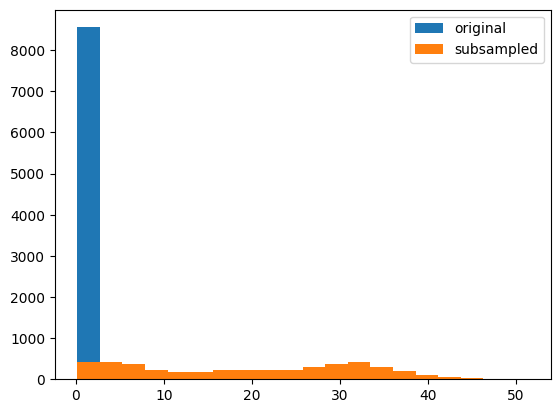

In [5]:
plt.hist(st_stimuli.speeds, bins=st_stimuli.bins_edges,label='original')
sub_speeds = st_stimuli.speeds[st_stimuli.bins_sub_ids!=-1]
plt.hist(sub_speeds, bins=st_stimuli.bins_edges,label='subsampled')
plt.legend()

## With stimuli vs Spontaneous

In [6]:
st_stimuli.print_tuned_cells()

Significantly tuned neurons: #14 
 [ 1  3  4  7 11 13 17 18 25 35 37 39 42 46]
Positive tuned neurons: #11 
 [ 1  3  4 11 13 17 25 35 37 42 46]
[0.11815153 0.06936879 0.02547183 0.05044089 0.03353328 0.03503375
 0.43956403 0.09516207 0.31465606 0.02836921 0.09005222]
Negative tuned neurons: #2 
 [ 7 39]
[-0.0235098  -0.06053784]
Non-monotonic tuned neurons: #1 
 [18]
[0.00838951]


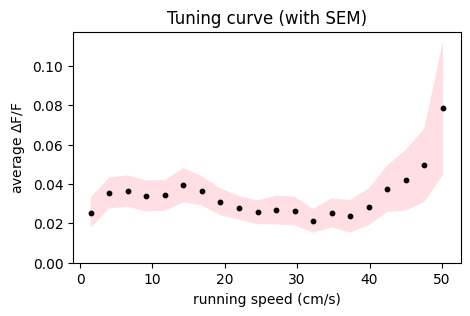

In [7]:
ax = st_stimuli.plot_tuning_curve(semcolor='pink')
ax.set_ylim(0)
ax.set_title("Tuning curve (with SEM)")
plt.show()

In [8]:
st_spont.print_tuned_cells()

Significantly tuned neurons: #3 
 [25 35 37]
Positive tuned neurons: #2 
 [25 35]
[0.5380154  0.35931997]
Negative tuned neurons: #0 
 []
[]
Non-monotonic tuned neurons: #1 
 [37]
[0.10694379]


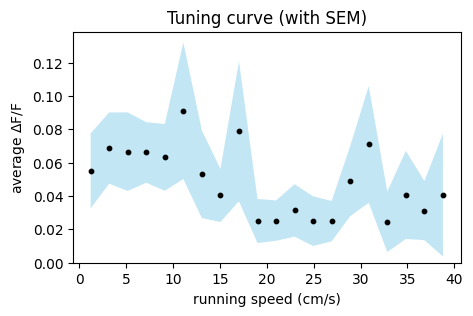

In [9]:
ax = st_spont.plot_tuning_curve(semcolor='skyblue')
ax.set_ylim(0)
ax.set_title("Tuning curve (with SEM)")
plt.show()

----

<Axes: ylabel='# f significant neurons'>

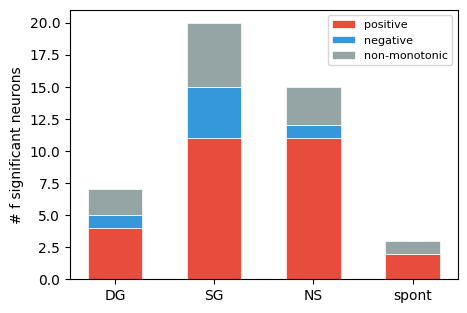

In [10]:
plot_monotonicity_stacked_bar({'DG': st_dg, 'SG':   
  st_sg, 'NS': st_ns, 'spont': st_spont})  

<Axes: ylabel='# f significant neurons'>

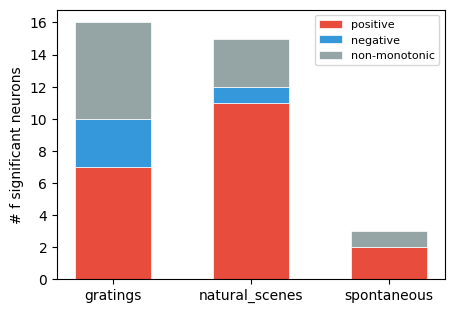

In [11]:
plot_monotonicity_stacked_bar({'gratings': st_gratings, 'natural_scenes': st_ns, 'spontaneous': st_spont})  

<Axes: ylabel='# f significant neurons'>

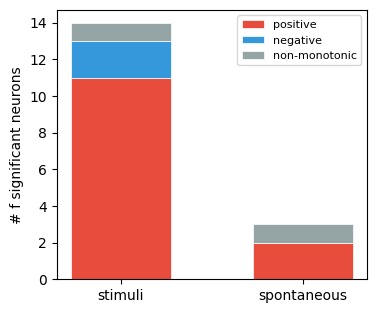

In [12]:
plot_monotonicity_stacked_bar({'stimuli': st_stimuli, 'spontaneous': st_spont}, figsize=(4,3.5))  

<Axes: xlabel='Spearman $\\rho$ (stimuli)', ylabel='Spearman $\\rho$ (spontaneous)'>

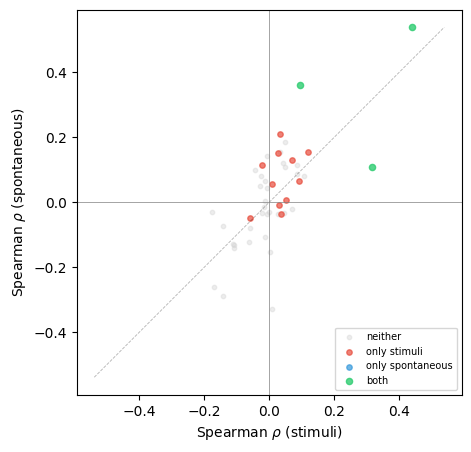

In [13]:
plot_rho_pairwise_scatter(st_stimuli, st_spont,           
  'stimuli', 'spontaneous')     

---